In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
from graphviz import Digraph

In [166]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data=data
        self._prev=set(_children)
        self._backward=lambda : None
        self.grad=0.0
        self._op=_op
        self.label=label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other): 
        other = other if isinstance(other,Value) else Value(other)
        out=Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward=_backward
        return out

    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out=Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other):  # other - self
        return other + (-self)

    def __truediv__(self, other):
        return self * other**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1- t**2) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad 
        out._backward = _backward
        
        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad=1.0
        for node in reversed(topo):
            node._backward()


a=Value(3, label='a')
b=Value(7, label='b')
c=Value(-5, label='c')
z=b*c; z.label='z'
x=a+z; x.label='x'
y=Value(4,label='y')
L=x*y; L.label='L'


In [167]:
2*a

Value(data=6)

In [168]:
print(x._prev)
print(x._op)

{Value(data=3), Value(data=-35)}
+


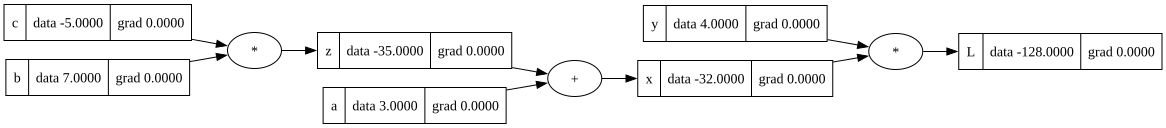

In [169]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

draw_dot(L)

In [170]:
#grad formula
# L=x*y
# dL/dx= ?y
# Formula: (f(x+h) - f(x)) / h
# ((x+h)*y - x *y) / h
# (x*y + h*y -x*y) / h
# h*y / h -> y

# dL/db


In [171]:
x.grad=4
y.grad=-32
a.grad=4
z.grad=4
b.grad=-20  # -5 * 4
c.grad=28  # 7 * 4

In [172]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
z=b*c
x=a+z
y=Value(4,label='y')
L=x*y
print(L.data)

-116.22399999999999


In [173]:
def lol():
    h=0.002
    a=Value(3, label='a')
    b=Value(7, label='b')
    c=Value(-5, label='c')
    z=b*c; z.label='z'
    x=a+z; x.label='x'
    y=Value(4,label='y')
    L=x*y; L.label='L'
    L1=L.data

    a=Value(3, label='a')
    b=Value(7, label='b')
    c=Value(-5, label='c')
    c.data+=h
    z=b*c; z.label='z'
    #a.data+=h
    x=a+z; x.label='x'
    y=Value(4,label='y')
    L=x*y; L.label='L'
    L2=L.data

    return ((L2-L1)/h)
lol()

27.999999999991587

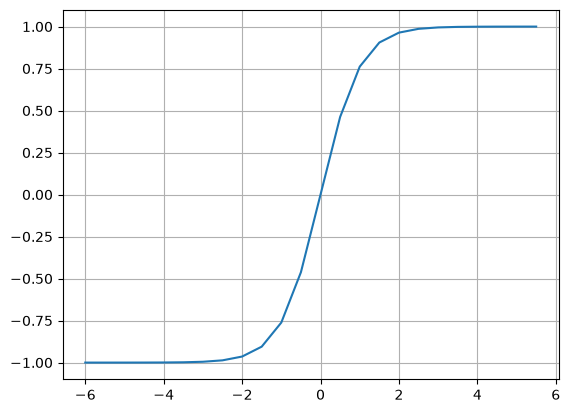

In [174]:
#tanh function

x=np.arange(-6,6, 0.5)
y=np.tanh(x)
plt.plot(x,y)
plt.grid()
plt.show()

In [175]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(1.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(2.0, label='w2')
# bias of the neuron
b = Value(4.88, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
r=n.tanh(); r.label='r'

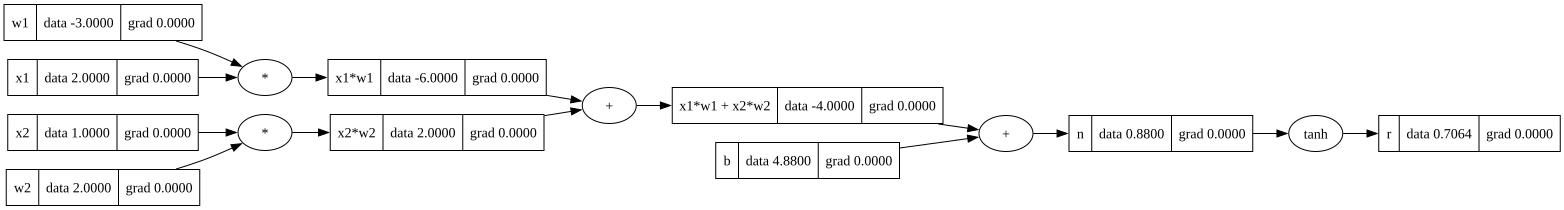

In [176]:
draw_dot(r)

In [177]:
r.backward()

In [178]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(r)
topo

[Value(data=4.88),
 Value(data=2.0),
 Value(data=1.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-4.0),
 Value(data=0.8799999999999999),
 Value(data=0.7064193203972352)]

#### Micrograd with torch

In [179]:
import torch

In [180]:
x1 = torch.Tensor([2.]).double() ; x1.requires_grad=True
w1 = torch.Tensor([-3.]).double() ; w1.requires_grad=True
x2 = torch.Tensor([1.]).double() ; x2.requires_grad=True
w2 = torch.Tensor([2.]).double() ; w2.requires_grad=True
b = torch.Tensor([4.88]).double() ; b.requires_grad=True

n= x1*w1 + x2*w2 + b
r= torch.tanh(n)

print(f" r: {r.data.item()}")
r.backward()

print('----')
print(f"x1 grad: {x1.grad.item()}")
print(f"w1 grad: {w1.grad.item()}")
print(f"x2 grad: {x2.grad.item()}")
print(f"w2 grad: {w2.grad.item()}")

 r: 0.7064193777288968
----
x1 grad: -1.5029149883073543
w1 grad: 1.0019433255382362
x2 grad: 1.0019433255382362
w2 grad: 0.5009716627691181


In [181]:
x1.dtype


torch.float64

In [193]:
import random
class Neuron:
    def __init__(self, num_in):
        self.w = [Value(random.uniform(-1,1)) for _ in range(num_in)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        out=act.tanh()
        return out

    def parameters(self):
      return self.w + [self.b]

class Layer:
    def __init__(self, num_in, num_out):
        self.neurons = [Neuron(num_in) for _ in range(num_out)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
      return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

x= [1.0, 2.0,3.0]
result = MLP(3, [4,4,1])
result(x)

Value(data=0.22615760542770375)

In [194]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ypred = [result(x) for x in xs]
ypred

[Value(data=0.5778989445716187),
 Value(data=0.7046461928169913),
 Value(data=0.36104484188835995),
 Value(data=0.789002398086765)]

In [195]:
loss = sum((yout-ygt)**2 for yout, ygt in zip(ys,ypred))
loss.backward()

In [197]:
result.layers[0].neurons[0].w[0].grad

0.4062690111928132

In [200]:
len(result.parameters())

41